In [ ]:
# Muneeza Mehboob
# Pattern Recgnition assignment

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample
from sklearn.preprocessing import StandardScaler

In [4]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **Load Sensors + Resample + Matrix X**

In [8]:
dataset_path = "/content/drive/MyDrive/Pattern Recognition/sensory_data/HAR_PR_dataset_ver2/examples"

target_subject = "Adeel"
target_activity = "walking"
target_event = "1"
TARGET_STEPS = 500

SELECTED_SENSORS = [
    "JinsAccelerometer",
    "JinsGyroscope",
    "PhoneAccelerometer",
    "PhoneGyroscope",
    "PhoneLinearAccelerometer",
    "PhoneGravity",
    "PhoneMagnetometer",
    "android.sensor.accelerometer",
    "android.sensor.gyroscope",
]

def get_activity_from_folder(folder_name):
    f = folder_name.lower()
    if "walking" in f:       return "walking"
    if "standing" in f:      return "standing"
    if "sitting" in f:       return "sitting"
    if "lying" in f:         return "lying"
    if "squatting" in f and "standup" not in f and "standsquat" not in f:
        return "squatting"
    if "bending" in f and "stand" not in f:  return "bending"
    if "bring" in f:         return "bring"
    if "drink" in f:         return "drink"
    if "eatsmall" in f:      return "eat"
    if "dryoff" in f and "shake" not in f and "byshake" not in f:
        return "dry"
    if "clean_floor" in f:   return "clean_floor"
    if "clean_surface" in f: return "clean_surface"
    return None

all_folders = sorted(os.listdir(dataset_path))
session_folders = [f for f in all_folders if f.endswith("_extracted")]

selected_session = None
for folder in session_folders:
    subject  = folder.split("_")[0]
    activity = get_activity_from_folder(folder)
    if subject == target_subject and activity == target_activity:
        selected_session = folder
        break

print(f"Selected Session : {selected_session}")

session_path = os.path.join(dataset_path, selected_session)

channels = []
print(f"\nLoading 9 sensors (3 axes each = 27 features):\n")

for sensor_name in SELECTED_SENSORS:
    file_name = f"{sensor_name}_Event_{target_event}.data"
    file_path = os.path.join(session_path, file_name)

    if not os.path.exists(file_path):
        print(f"  NOT FOUND: {file_name}")
        continue

    df           = pd.read_csv(file_path, header=None, sep=';')
    sensor_data  = df.iloc[:, 1:4].values.astype(float)
    resampled    = resample(sensor_data, TARGET_STEPS)
    channels.append(resampled)

    print(f"  {sensor_name}")
    print(f"    Original  : {sensor_data.shape}")
    print(f"    Resampled : {resampled.shape}")

X_raw = np.hstack(channels)

print(f"\nFinal Matrix X_raw shape : {X_raw.shape}")
print(f"  Rows    (T) = {X_raw.shape[0]}  [500 timesteps @ 100Hz]")
print(f"  Columns (F) = {X_raw.shape[1]}  [9 sensors x 3 axes = 27]")


Selected Session : Adeel_Walking_1_extracted

Loading 9 sensors (3 axes each = 27 features):

  JinsAccelerometer
    Original  : (99, 3)
    Resampled : (500, 3)
  JinsGyroscope
    Original  : (99, 3)
    Resampled : (500, 3)
  PhoneAccelerometer
    Original  : (1007, 3)
    Resampled : (500, 3)
  PhoneGyroscope
    Original  : (1006, 3)
    Resampled : (500, 3)
  PhoneLinearAccelerometer
    Original  : (1006, 3)
    Resampled : (500, 3)
  PhoneGravity
    Original  : (1007, 3)
    Resampled : (500, 3)
  PhoneMagnetometer
    Original  : (501, 3)
    Resampled : (500, 3)
  android.sensor.accelerometer
    Original  : (497, 3)
    Resampled : (500, 3)
  android.sensor.gyroscope
    Original  : (498, 3)
    Resampled : (500, 3)

Final Matrix X_raw shape : (500, 27)
  Rows    (T) = 500  [500 timesteps @ 100Hz]
  Columns (F) = 27  [9 sensors x 3 axes = 27]


# **Standardize + Visualize X**

X shape : (500, 27)
  mean  : 0.000000  (should be ~0)
  std   : 1.000000   (should be ~1)
  min   : -4.3511
  max   : 4.9156


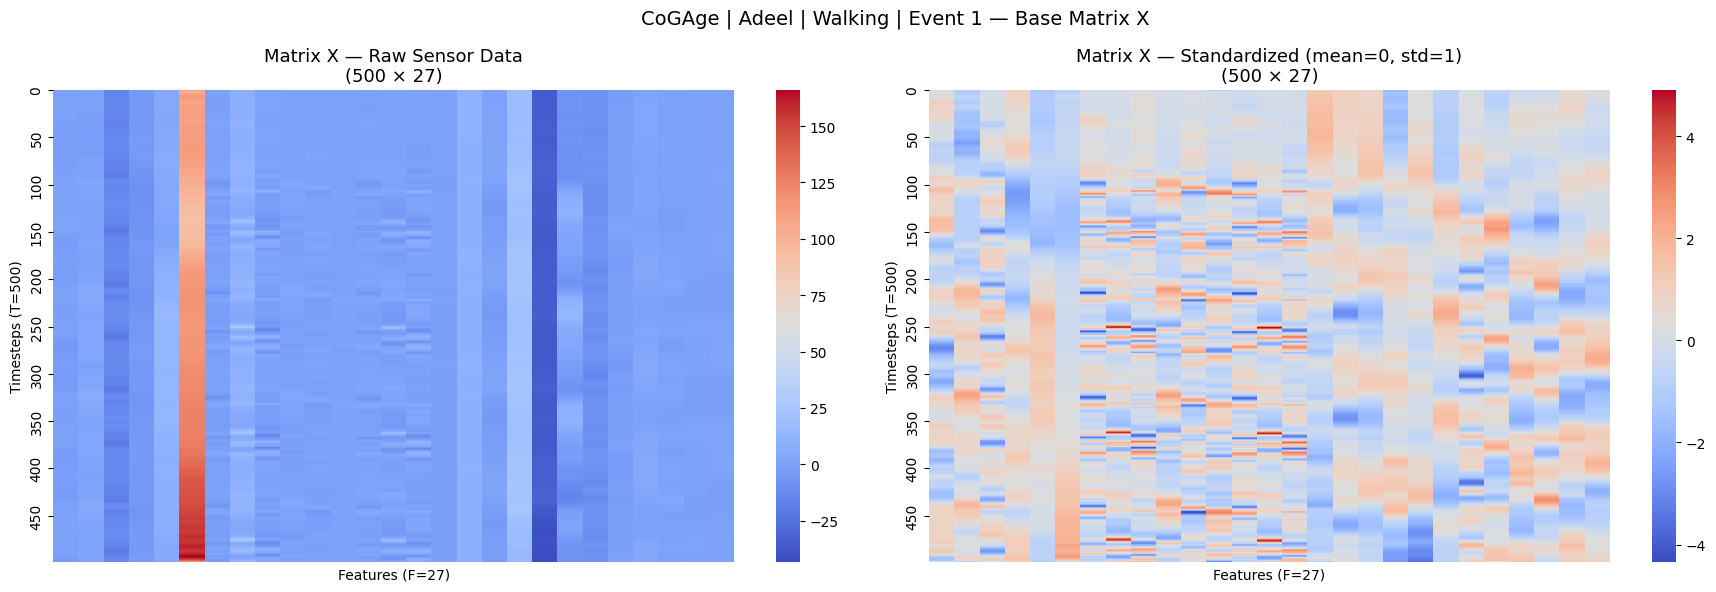


Raw    — min: -43.4864, max: 166.1358, mean: 3.6379
Scaled — min: -4.3511,  max: 4.9156,  mean: 0.000000


In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

T, F = X.shape
print(f"X shape : {X.shape}")
print(f"  mean  : {X.mean():.6f}  (should be ~0)")
print(f"  std   : {X.std():.6f}   (should be ~1)")
print(f"  min   : {X.min():.4f}")
print(f"  max   : {X.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(X_raw, ax=axes[0], cmap="coolwarm",
            xticklabels=False, yticklabels=50, cbar=True)
axes[0].set_title("Matrix X — Raw Sensor Data\n(500 × 27)", fontsize=13)
axes[0].set_xlabel("Features (F=27)")
axes[0].set_ylabel("Timesteps (T=500)")

sns.heatmap(X, ax=axes[1], cmap="coolwarm",
            xticklabels=False, yticklabels=50, cbar=True)
axes[1].set_title("Matrix X — Standardized (mean=0, std=1)\n(500 × 27)", fontsize=13)
axes[1].set_xlabel("Features (F=27)")
axes[1].set_ylabel("Timesteps (T=500)")

plt.suptitle("CoGAge | Adeel | Walking | Event 1 — Base Matrix X", fontsize=14)
plt.tight_layout()
plt.savefig("matrix_X.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRaw    — min: {X_raw.min():.4f}, max: {X_raw.max():.4f}, mean: {X_raw.mean():.4f}")
print(f"Scaled — min: {X.min():.4f},  max: {X.max():.4f},  mean: {X.mean():.6f}")


# **Softmax Function + Level 1**

LEVEL 1 : Softmax(X · Xᵀ) · X
Input X  : (500, 27)  (T=500, F=27)
X · Xᵀ            : (500, 500)
Softmax(X·Xᵀ)     : (500, 500)
Row sum check     : 1.0  (should be 1.0)
Level 1 Output    : (500, 27)


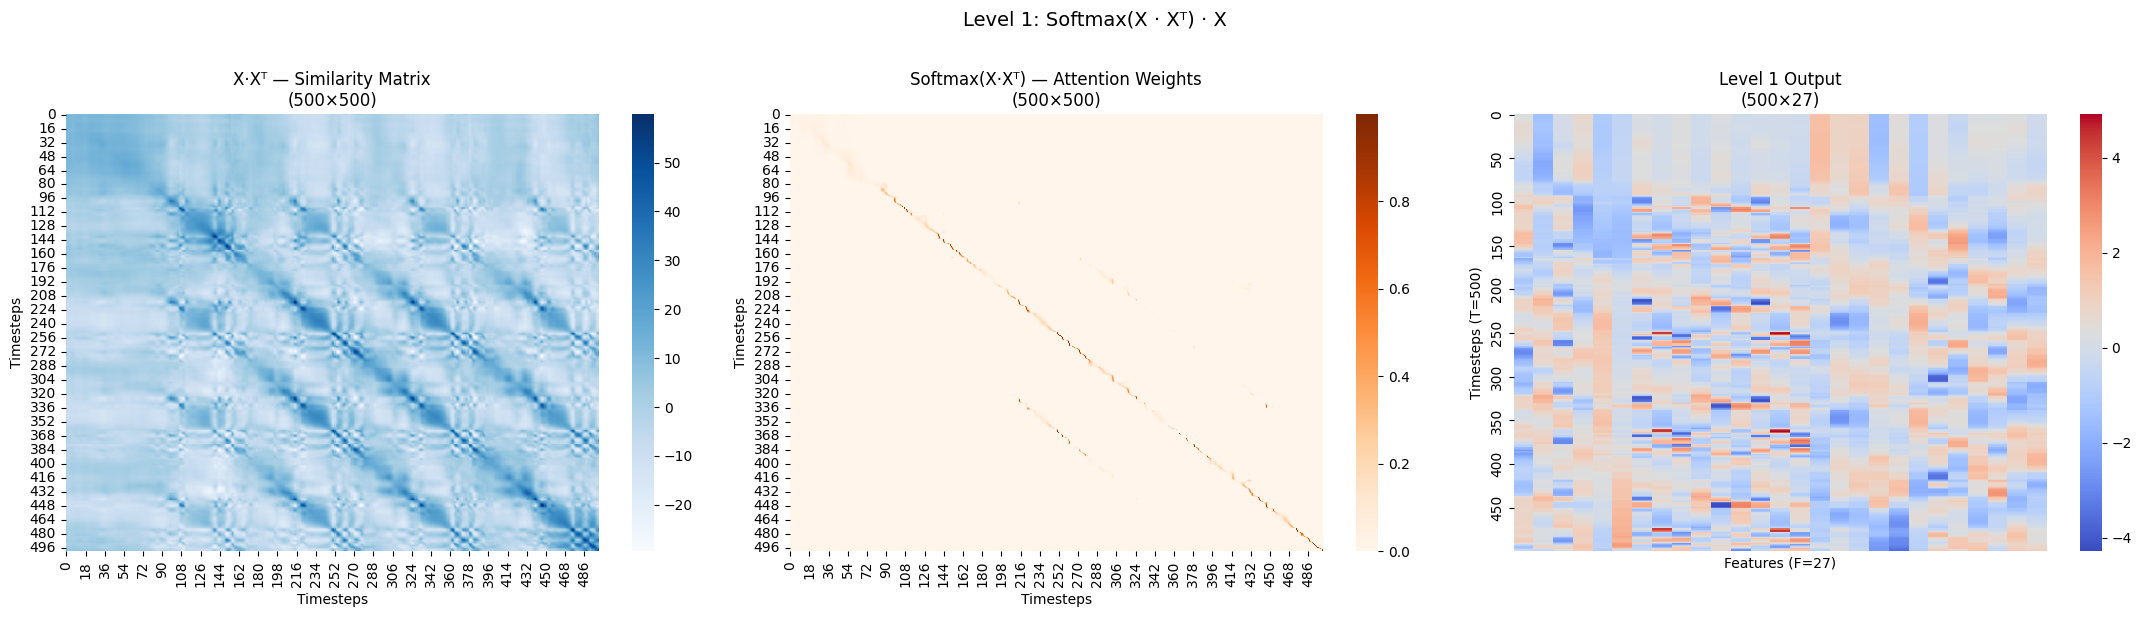


Level 1 Output summary:
  shape : (500, 27)
  min   : -4.2801
  max   : 4.9155
  mean  : 0.0011


In [10]:
def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z     = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

print("=" * 55)
print("LEVEL 1 : Softmax(X · Xᵀ) · X")
print("=" * 55)
print(f"Input X  : {X.shape}  (T={T}, F={F})")

similarity_L1 = X @ X.T
attention_L1  = softmax(similarity_L1)
L1_output     = attention_L1 @ X

print(f"X · Xᵀ            : {similarity_L1.shape}")
print(f"Softmax(X·Xᵀ)     : {attention_L1.shape}")
print(f"Row sum check     : {np.round(attention_L1[0].sum(), 6)}  (should be 1.0)")
print(f"Level 1 Output    : {L1_output.shape}")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(similarity_L1, ax=axes[0], cmap="Blues", cbar=True)
axes[0].set_title(f"X·Xᵀ — Similarity Matrix\n({T}×{T})", fontsize=12)
axes[0].set_xlabel("Timesteps")
axes[0].set_ylabel("Timesteps")

sns.heatmap(attention_L1, ax=axes[1], cmap="Oranges", cbar=True)
axes[1].set_title(f"Softmax(X·Xᵀ) — Attention Weights\n({T}×{T})", fontsize=12)
axes[1].set_xlabel("Timesteps")
axes[1].set_ylabel("Timesteps")

sns.heatmap(L1_output, ax=axes[2], cmap="coolwarm",
            xticklabels=False, yticklabels=50, cbar=True)
axes[2].set_title(f"Level 1 Output\n({T}×{F})", fontsize=12)
axes[2].set_xlabel("Features (F=27)")
axes[2].set_ylabel("Timesteps (T=500)")

plt.suptitle("Level 1: Softmax(X · Xᵀ) · X", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("level1.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLevel 1 Output summary:")
print(f"  shape : {L1_output.shape}")
print(f"  min   : {L1_output.min():.4f}")
print(f"  max   : {L1_output.max():.4f}")
print(f"  mean  : {L1_output.mean():.4f}")


# **PE → Attention**

LEVEL 2 : Project(X→128) + PE + Softmax(Z·Zᵀ)·Z
Input X  : (500, 27)  →  d_model = 128
U shape         : (27, 128)
X_proj = X·U    : (500, 128)
PE shape        : (500, 128)  (min=-1.00, max=1.00)
Z = X_proj + PE : (500, 128)
Z·Zᵀ            : (500, 500)
Softmax(Z·Zᵀ)   : (500, 500)
Row sum check   : 1.0
Level 2 Output  : (500, 128)


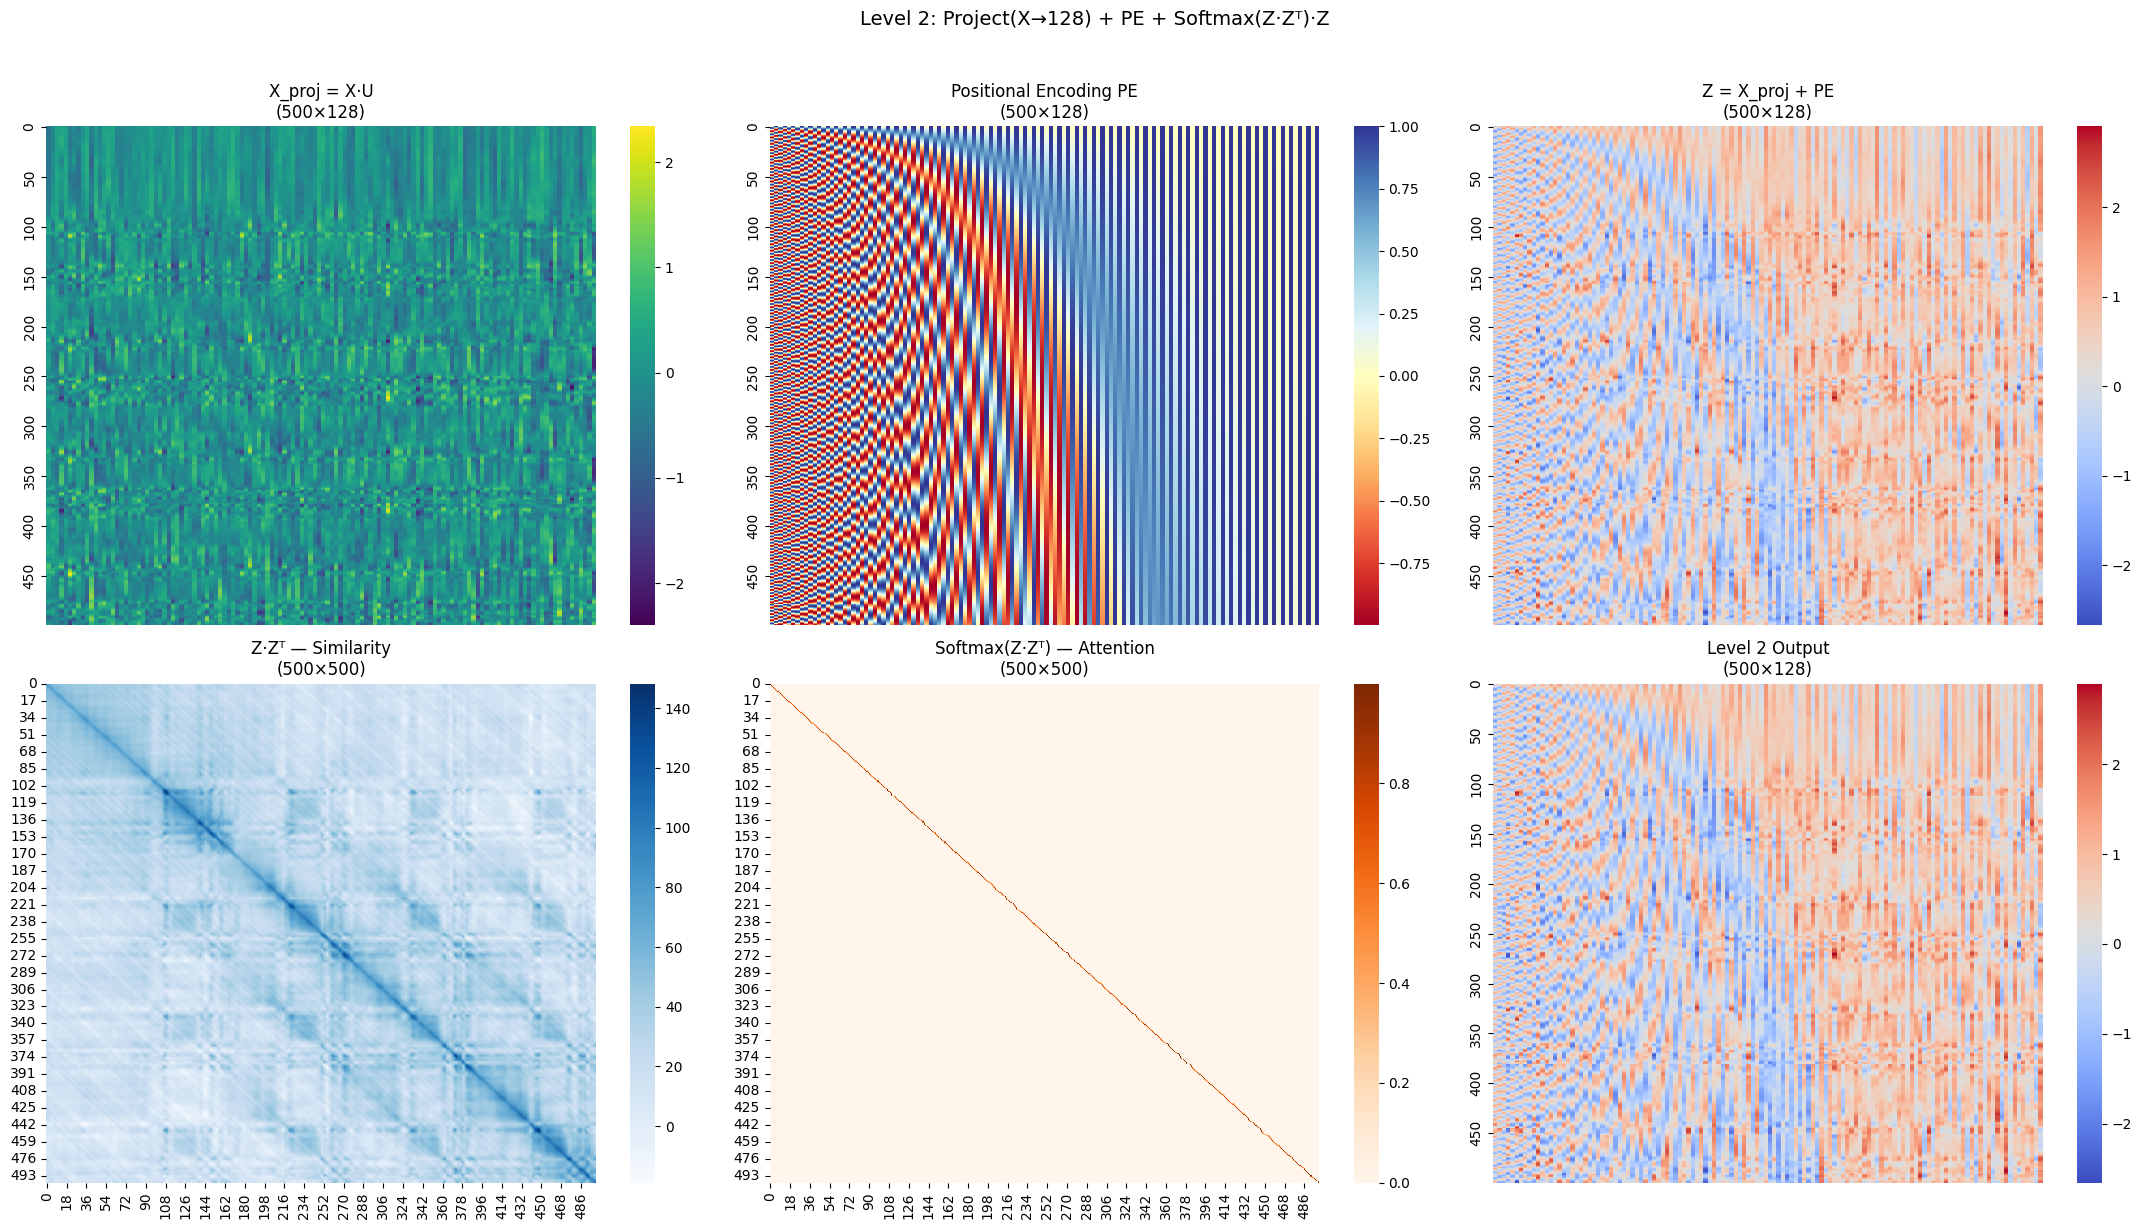


Level 2 Output summary:
  shape : (500, 128)
  min   : -2.6539
  max   : 2.8955
  mean  : 0.2676


In [11]:
d_model = 128

print("=" * 55)
print("LEVEL 2 : Project(X→128) + PE + Softmax(Z·Zᵀ)·Z")
print("=" * 55)
print(f"Input X  : {X.shape}  →  d_model = {d_model}")

np.random.seed(42)
U      = np.random.randn(F, d_model) / np.sqrt(d_model)
X_proj = X @ U
print(f"U shape         : {U.shape}")
print(f"X_proj = X·U    : {X_proj.shape}")

def positional_encoding(T, d_model):
    PE = np.zeros((T, d_model))
    for pos in range(T):
        for i in range(0, d_model, 2):
            PE[pos, i]   = np.sin(pos / (10000 ** (i / d_model)))
            if i + 1 < d_model:
                PE[pos, i+1] = np.cos(pos / (10000 ** (i / d_model)))
    return PE

PE = positional_encoding(T, d_model)
Z  = X_proj + PE

print(f"PE shape        : {PE.shape}  (min={PE.min():.2f}, max={PE.max():.2f})")
print(f"Z = X_proj + PE : {Z.shape}")

similarity_L2 = Z @ Z.T
attention_L2  = softmax(similarity_L2)
L2_output     = attention_L2 @ Z

print(f"Z·Zᵀ            : {similarity_L2.shape}")
print(f"Softmax(Z·Zᵀ)   : {attention_L2.shape}")
print(f"Row sum check   : {np.round(attention_L2[0].sum(), 6)}")
print(f"Level 2 Output  : {L2_output.shape}")

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

sns.heatmap(X_proj, ax=axes[0,0], cmap="viridis",
            xticklabels=False, yticklabels=50, cbar=True)
axes[0,0].set_title(f"X_proj = X·U\n({T}×{d_model})", fontsize=12)

sns.heatmap(PE, ax=axes[0,1], cmap="RdYlBu",
            xticklabels=False, yticklabels=50, cbar=True)
axes[0,1].set_title(f"Positional Encoding PE\n({T}×{d_model})", fontsize=12)

sns.heatmap(Z, ax=axes[0,2], cmap="coolwarm",
            xticklabels=False, yticklabels=50, cbar=True)
axes[0,2].set_title(f"Z = X_proj + PE\n({T}×{d_model})", fontsize=12)

sns.heatmap(similarity_L2, ax=axes[1,0], cmap="Blues", cbar=True)
axes[1,0].set_title(f"Z·Zᵀ — Similarity\n({T}×{T})", fontsize=12)

sns.heatmap(attention_L2, ax=axes[1,1], cmap="Oranges", cbar=True)
axes[1,1].set_title(f"Softmax(Z·Zᵀ) — Attention\n({T}×{T})", fontsize=12)

sns.heatmap(L2_output, ax=axes[1,2], cmap="coolwarm",
            xticklabels=False, yticklabels=50, cbar=True)
axes[1,2].set_title(f"Level 2 Output\n({T}×{d_model})", fontsize=12)

plt.suptitle("Level 2: Project(X→128) + PE + Softmax(Z·Zᵀ)·Z", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("level2.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLevel 2 Output summary:")
print(f"  shape : {L2_output.shape}")
print(f"  min   : {L2_output.min():.4f}")
print(f"  max   : {L2_output.max():.4f}")
print(f"  mean  : {L2_output.mean():.4f}")


# **Q-K-V Attention on Z**

LEVEL 3 : Scaled Q-K-V Attention on Z
Input Z  : (500, 128)  (T=500, d_model=128)
Q = Z·Wq        : (500, 128)
K = Z·Wk        : (500, 128)
V = Z·Wv        : (500, 128)
Q·Kᵀ/√128      : (500, 500)
Softmax(scores) : (500, 500)
Row sum check   : 1.0
Level 3 Output  : (500, 128)


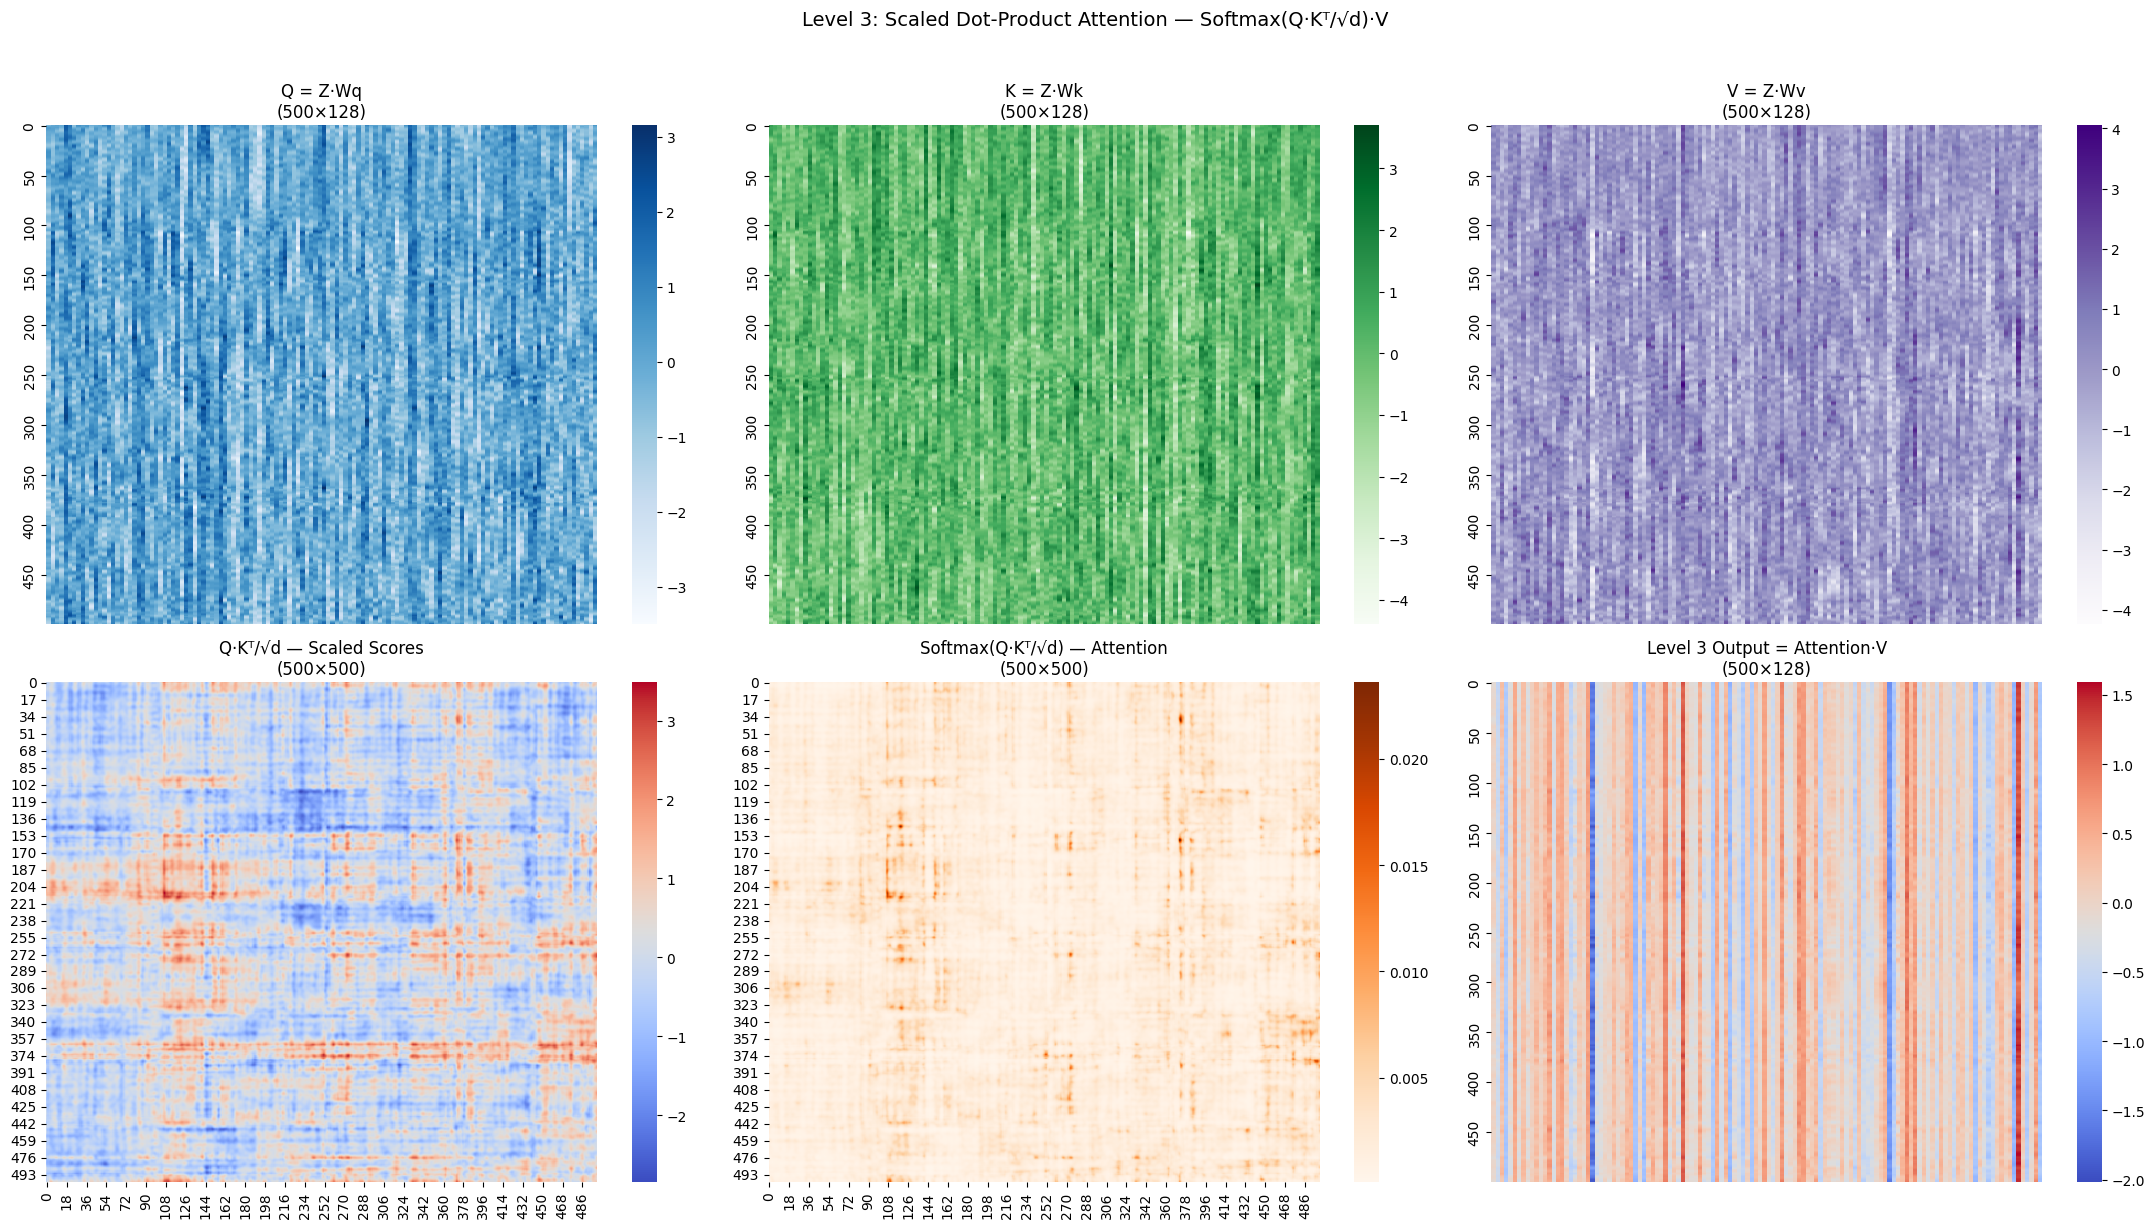


Level 3 Output summary:
  shape : (500, 128)
  min   : -2.0150
  max   : 1.5905
  mean  : -0.0258


In [12]:
print("=" * 55)
print("LEVEL 3 : Scaled Q-K-V Attention on Z")
print("=" * 55)
print(f"Input Z  : {Z.shape}  (T={T}, d_model={d_model})")

np.random.seed(42)
Wq = np.random.randn(d_model, d_model) / np.sqrt(d_model)
Wk = np.random.randn(d_model, d_model) / np.sqrt(d_model)
Wv = np.random.randn(d_model, d_model) / np.sqrt(d_model)

Q = Z @ Wq
K = Z @ Wk
V = Z @ Wv

print(f"Q = Z·Wq        : {Q.shape}")
print(f"K = Z·Wk        : {K.shape}")
print(f"V = Z·Wv        : {V.shape}")

d_k        = d_model
scores_L3  = Q @ K.T / np.sqrt(d_k)
attention_L3 = softmax(scores_L3)
L3_output    = attention_L3 @ V

print(f"Q·Kᵀ/√{d_k}      : {scores_L3.shape}")
print(f"Softmax(scores) : {attention_L3.shape}")
print(f"Row sum check   : {np.round(attention_L3[0].sum(), 6)}")
print(f"Level 3 Output  : {L3_output.shape}")

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

sns.heatmap(Q, ax=axes[0,0], cmap="Blues",
            xticklabels=False, yticklabels=50, cbar=True)
axes[0,0].set_title(f"Q = Z·Wq\n({T}×{d_model})", fontsize=12)

sns.heatmap(K, ax=axes[0,1], cmap="Greens",
            xticklabels=False, yticklabels=50, cbar=True)
axes[0,1].set_title(f"K = Z·Wk\n({T}×{d_model})", fontsize=12)

sns.heatmap(V, ax=axes[0,2], cmap="Purples",
            xticklabels=False, yticklabels=50, cbar=True)
axes[0,2].set_title(f"V = Z·Wv\n({T}×{d_model})", fontsize=12)

sns.heatmap(scores_L3, ax=axes[1,0], cmap="coolwarm", cbar=True)
axes[1,0].set_title(f"Q·Kᵀ/√d — Scaled Scores\n({T}×{T})", fontsize=12)

sns.heatmap(attention_L3, ax=axes[1,1], cmap="Oranges", cbar=True)
axes[1,1].set_title(f"Softmax(Q·Kᵀ/√d) — Attention\n({T}×{T})", fontsize=12)

sns.heatmap(L3_output, ax=axes[1,2], cmap="coolwarm",
            xticklabels=False, yticklabels=50, cbar=True)
axes[1,2].set_title(f"Level 3 Output = Attention·V\n({T}×{d_model})", fontsize=12)

plt.suptitle("Level 3: Scaled Dot-Product Attention — Softmax(Q·Kᵀ/√d)·V", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("level3.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLevel 3 Output summary:")
print(f"  shape : {L3_output.shape}")
print(f"  min   : {L3_output.min():.4f}")
print(f"  max   : {L3_output.max():.4f}")
print(f"  mean  : {L3_output.mean():.4f}")

# **Final Comparison**

                          FINAL SUMMARY                          
  Dataset  : CoGAge | Adeel | Walking | Event 1
  Sensors  : 9 × 3 axes = 27 features
  Resample : 100Hz → 500 timesteps
  d_model  : 128

  Level                  Shape        Min        Max       Mean
  ------------------------------------------------------------
  X (scaled)         (500, 27)    -4.3511     4.9156     0.0000
  L1 output          (500, 27)    -4.2801     4.9155     0.0011
  L2 output         (500, 128)    -2.6539     2.8955     0.2676
  L3 output         (500, 128)    -2.0150     1.5905    -0.0258


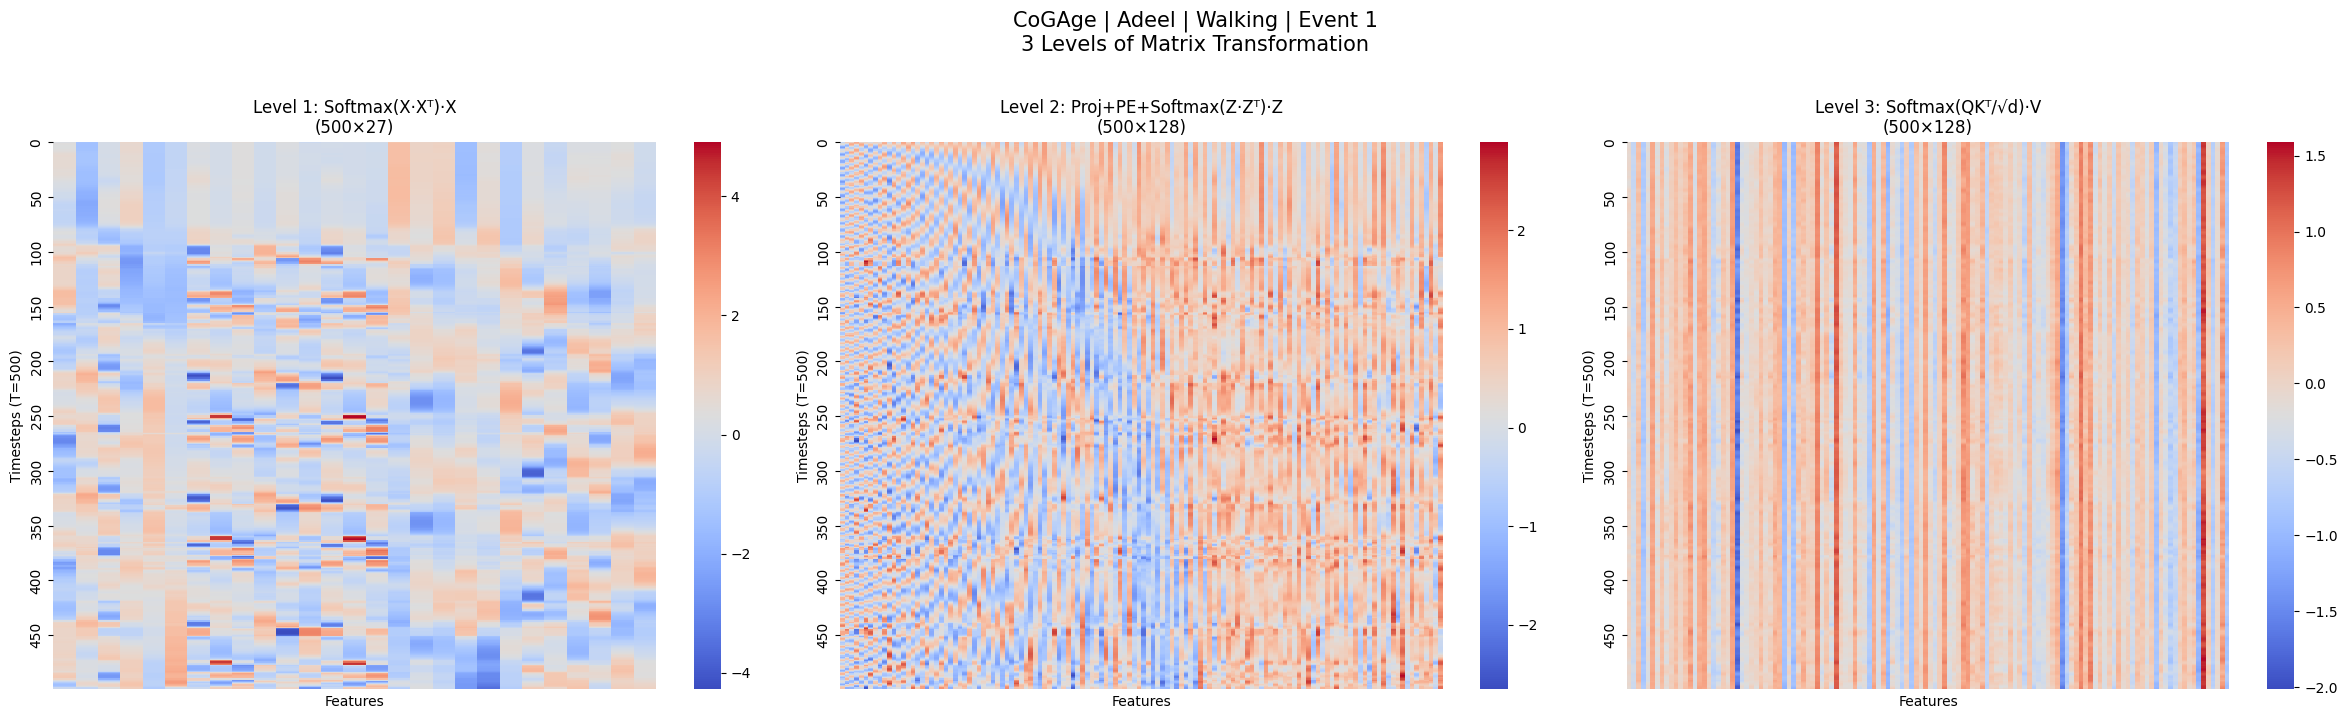

In [13]:
print("=" * 65)
print(f"{'FINAL SUMMARY':^65}")
print("=" * 65)
print(f"  Dataset  : CoGAge | Adeel | Walking | Event 1")
print(f"  Sensors  : 9 × 3 axes = 27 features")
print(f"  Resample : 100Hz → {TARGET_STEPS} timesteps")
print(f"  d_model  : {d_model}")
print("=" * 65)
print(f"\n  {'Level':<12} {'Shape':>15} {'Min':>10} {'Max':>10} {'Mean':>10}")
print(f"  {'-'*60}")
print(f"  {'X (scaled)':<12} {str(X.shape):>15} {X.min():>10.4f} {X.max():>10.4f} {X.mean():>10.4f}")
print(f"  {'L1 output':<12} {str(L1_output.shape):>15} {L1_output.min():>10.4f} {L1_output.max():>10.4f} {L1_output.mean():>10.4f}")
print(f"  {'L2 output':<12} {str(L2_output.shape):>15} {L2_output.min():>10.4f} {L2_output.max():>10.4f} {L2_output.mean():>10.4f}")
print(f"  {'L3 output':<12} {str(L3_output.shape):>15} {L3_output.min():>10.4f} {L3_output.max():>10.4f} {L3_output.mean():>10.4f}")
print("=" * 65)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

plots = [
    (L1_output, f"Level 1: Softmax(X·Xᵀ)·X\n({T}×{F})"),
    (L2_output, f"Level 2: Proj+PE+Softmax(Z·Zᵀ)·Z\n({T}×{d_model})"),
    (L3_output, f"Level 3: Softmax(QKᵀ/√d)·V\n({T}×{d_model})"),
]

for i, (out, title) in enumerate(plots):
    sns.heatmap(out, ax=axes[i], cmap="coolwarm",
                xticklabels=False, yticklabels=50, cbar=True)
    axes[i].set_title(title, fontsize=12)
    axes[i].set_xlabel("Features")
    axes[i].set_ylabel("Timesteps (T=500)")

plt.suptitle(
    "CoGAge | Adeel | Walking | Event 1\n3 Levels of Matrix Transformation",
    fontsize=15, y=1.02
)
plt.tight_layout()
plt.savefig("all_levels_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
